# Dimensionality reduction on NK-cell mass cytometry data (Horowitz et al., 2013)

This notebook covers the dimensionality-reduction part of the group project: preprocessing,
PCA / t-SNE / UMAP with a documented and justified choice of parameters, example
visualizations, and a quantitative comparison of the resulting embeddings using both
neighbor-based and non-neighbor-based measures.

Clustering itself (Leiden, cluster interpretation) is out of scope here and handled in the
next notebook — this notebook ends by exporting the embeddings needed for that step.

**Structure**
1. Load data
2. Preprocessing (arcsinh transform, marker filtering, scaling)
3. Sanity check: is the donor-balanced subsample representative for rare subsets?
4. PCA (component selection, reconstruction error, visualization)
5. Building a fixed subsample for expensive hyperparameter sweeps
6. t-SNE parameter sweep
7. UMAP parameter sweep
8. Final embeddings (subsample-scale for fair comparison, full-scale for biological exploration)
9. Visualizations
10. Quantitative comparison of the three techniques
11. Summary / results
12. Export for downstream clustering

In [1]:
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist
from scipy.spatial import procrustes
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, trustworthiness
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
import umap
import anndata as ad
import scanpy as sc
import math

RANDOM_SEED = 42
sns.set_theme(style="whitegrid", context="notebook")
sc.settings.verbosity = 1

c:\Users\marie\anaconda3\envs\ssbi-group-project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load data

Artifacts exported from `01_data_exploration.ipynb`.

In [2]:
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "environment.yml").exists() and (candidate / "NK_cell_dataset").exists():
            return candidate
    raise FileNotFoundError("Project root not found.")

PROJECT_ROOT = find_project_root(Path.cwd())
ARTIFACT_DIR = PROJECT_ROOT

# Donor-balanced subsample (~2,000-3,000 cells/donor) used for most of this notebook,
# and the full (unsampled) data used only to check whether that subsample is representative.
nk_balanced_raw = pd.read_parquet(ARTIFACT_DIR / "nk_balanced_raw.parquet")
nk_full_raw = pd.read_parquet(ARTIFACT_DIR / "nk_full_raw.parquet")

channel_table = pd.read_parquet(ARTIFACT_DIR / "channel_table.parquet")
labels = pd.read_csv(ARTIFACT_DIR / "labels.csv")

analysis_markers = channel_table.loc[channel_table["analysis_marker"], "marker_name_pns"].tolist()
meta_cols = ["sample_id", "label", "clinical_group"]
nk_filtered = nk_balanced_raw[meta_cols + analysis_markers].copy()

print(f"Loaded {len(nk_filtered):,} cells x {len(analysis_markers)} markers "
      f"from {nk_filtered['sample_id'].nunique()} donors")

Loaded 40,000 cells x 37 markers from 20 donors


## 2. Preprocessing

Mass cytometry (CyTOF) counts are arcsinh-transformed to stabilize variance and separate the
characteristic bimodal (negative/positive) marker distributions, then z-scored so all markers
contribute comparably to distance-based methods (PCA/t-SNE/UMAP all operate on Euclidean
distance, so markers on very different scales would otherwise dominate).

We first pick an arcsinh cofactor by checking which value gives the cleanest bimodal
separation on markers with a well-known negative/positive split (CD3, CD56, CD16, CD57).

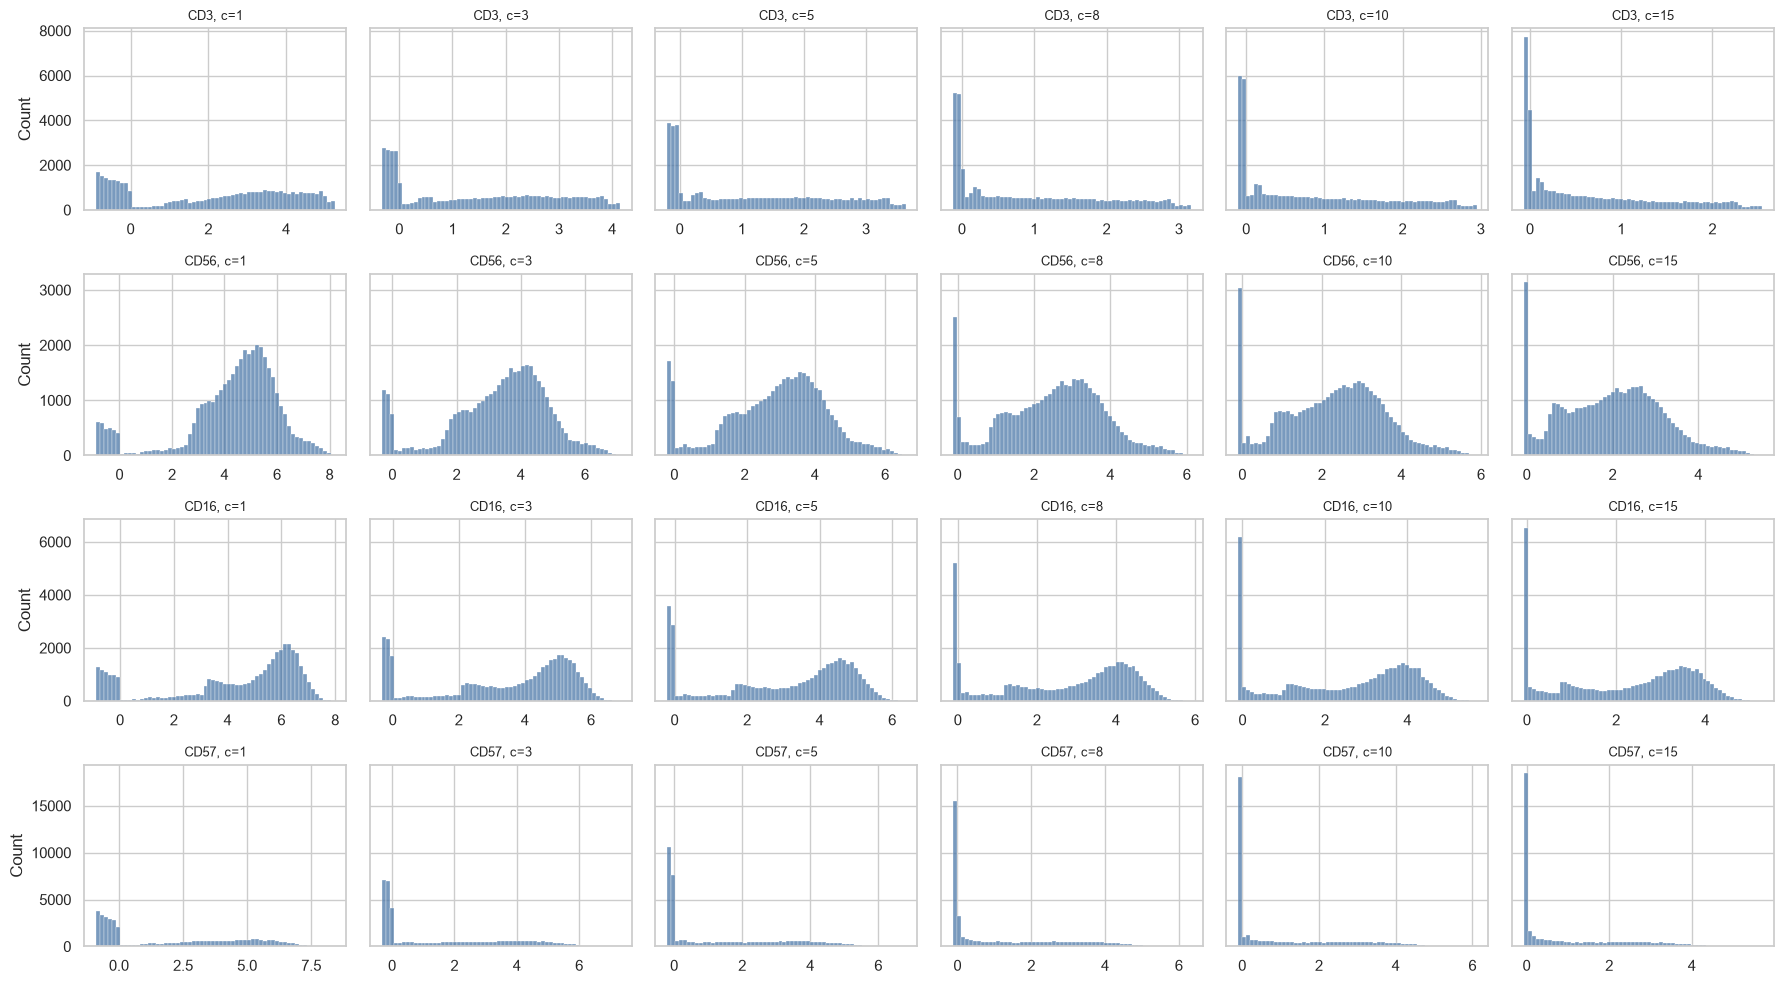

In [3]:
def arcsinh_transform(frame, marker_names, cofactor):
    out = frame.copy()
    out[marker_names] = np.arcsinh(out[marker_names] / cofactor)
    return out

cofactor_candidates = [1, 3, 5, 8, 10, 15]
diagnostic_markers = ["CD3", "CD56", "CD16", "CD57"]  # known bimodal markers

fig, axes = plt.subplots(len(diagnostic_markers), len(cofactor_candidates),
                          figsize=(3 * len(cofactor_candidates), 2.5 * len(diagnostic_markers)),
                          sharey="row")
for row, marker in enumerate(diagnostic_markers):
    for col, cofactor in enumerate(cofactor_candidates):
        transformed = np.arcsinh(nk_filtered[marker] / cofactor)
        sns.histplot(transformed, bins=60, ax=axes[row, col], color="#4c78a8")
        axes[row, col].set_title(f"{marker}, c={cofactor}", fontsize=9)
        axes[row, col].set_xlabel("")
plt.tight_layout()
plt.show()

**Cofactor choice: 5.** This is also the standard default for CyTOF data (as opposed to ~150
for fluorescence flow cytometry, which has a different noise model). In the grid above, c=5
gives the cleanest separation between the negative and positive modes for all four diagnostic
markers — smaller cofactors (1-3) compress the positive peak against the axis and blur the
valley between modes, larger cofactors (10-15) over-compress the whole distribution and merge
the two modes together.

In [4]:
ARCSINH_COFACTOR = 5.0
nk_transformed = arcsinh_transform(nk_filtered, analysis_markers, ARCSINH_COFACTOR)

# Also transform the full (unsampled) data with the same cofactor -- needed later for the
# subsample-representativeness check and for full-scale marker overlays.
nk_full_transformed = arcsinh_transform(nk_full_raw, analysis_markers, ARCSINH_COFACTOR)

print(f"Transformed {len(nk_transformed):,} cells (balanced subsample) "
      f"and {len(nk_full_transformed):,} cells (full data)")

Transformed 40,000 cells (balanced subsample) and 261,593 cells (full data)


Everything downstream is built on a single `AnnData` object and a single feature matrix
(`adata.X`), rather than several separately-built copies, so there is exactly one definition
of "the data" to keep track of.

In [5]:
obs = nk_transformed[["sample_id", "label", "clinical_group"]].reset_index(drop=True)
X_arcsinh = nk_transformed[analysis_markers].to_numpy()

adata = ad.AnnData(X=X_arcsinh, obs=obs, var=pd.DataFrame(index=analysis_markers))
adata.layers["arcsinh"] = adata.X.copy()  # snapshot before variance filtering/scaling
print(adata)

AnnData object with n_obs × n_vars = 40000 × 37
    obs: 'sample_id', 'label', 'clinical_group'
    layers: None (.X), 'arcsinh'


c:\Users\marie\anaconda3\envs\ssbi-group-project\Lib\functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


**Near-zero-variance marker filtering.** A marker with almost no variance across cells
(e.g. an "always on" or "always off" marker, or one where the panel simply didn't work well)
contributes noise rather than signal once z-scored -- scaling inflates its tiny variance to
unit variance, so it ends up weighted the same as an informative marker. We drop markers below
a variance threshold, but only after checking the list isn't hiding a biologically meaningful
always-on/off marker.

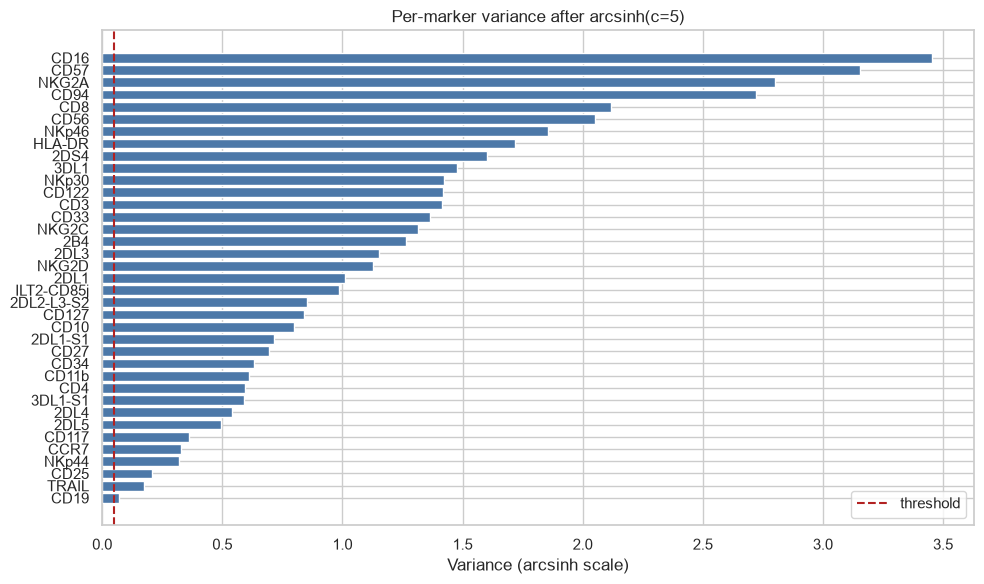

In [6]:
marker_variance = pd.Series(adata.layers["arcsinh"].var(axis=0), index=adata.var_names).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(marker_variance.index, marker_variance.values, color="#4c78a8")
ax.axvline(0.05, color="firebrick", linestyle="--", label="threshold")
ax.set(xlabel="Variance (arcsinh scale)", title="Per-marker variance after arcsinh(c=5)")
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
LOW_VARIANCE_THRESHOLD = 0.05

low_variance_markers = marker_variance[marker_variance < LOW_VARIANCE_THRESHOLD].index.tolist()
print(f"Flagged as low-variance ({len(low_variance_markers)}): {low_variance_markers}")

kept_markers = [m for m in analysis_markers if m not in low_variance_markers]
adata = adata[:, kept_markers].copy()
print(f"Retained {adata.n_vars} of {len(analysis_markers)} markers")

Flagged as low-variance (0): []
Retained 37 of 37 markers


In [8]:
# z-score each retained marker (mean 0, unit variance); this becomes THE feature matrix
# used for everything downstream (PCA, t-SNE, UMAP all read from adata.X / adata.obsm).
sc.pp.scale(adata, max_value=None)
adata.layers["scaled"] = adata.X.copy()
X = adata.X  # (n_cells, n_kept_markers), z-scored

## 3. Is the donor-balanced subsample representative?

Everything in this notebook runs on the 2,000-cells/donor balanced subsample rather
than the full dataset, mainly for speed. Before relying on that subsample for the rest of the
analysis, we check whether it distorts detection of a known **rare** subset: the
NKG2C+/CD57+ "adaptive" NK cells the paper associates with CMV infection. Rare subsets are
exactly what aggressive subsampling is most likely to distort.

Positivity thresholds are estimated with a simple, transparent approach: fit a two-component
Gaussian mixture per marker on the full data and take the crossover point between the
components.

In [9]:
def estimate_positive_threshold(values, random_state=RANDOM_SEED):
    values = values.to_numpy().reshape(-1, 1)
    gmm = GaussianMixture(n_components=2, random_state=random_state).fit(values)
    means = gmm.means_.ravel()
    neg_component, pos_component = np.argsort(means)
    grid = np.linspace(means[neg_component], means[pos_component], 1000).reshape(-1, 1)
    posterior_pos = gmm.predict_proba(grid)[:, pos_component]
    crossover_idx = np.argmax(posterior_pos > 0.5)
    return grid[crossover_idx, 0]

thresholds = {
    marker: estimate_positive_threshold(nk_full_transformed[marker])
    for marker in ["NKG2C", "CD57"]
}
print(thresholds)

c:\Users\marie\anaconda3\envs\ssbi-group-project\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


{'NKG2C': np.float64(0.0858454660137142), 'CD57': np.float64(0.08457670597770588)}


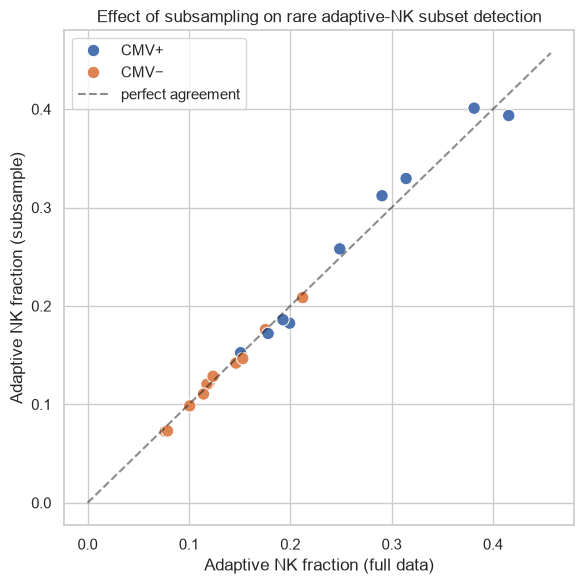

,full_fraction,subsample_fraction,subsample_count,clinical_group
sample_id,,,,


In [10]:
def flag_double_positive(frame, thresholds):
    return (frame["NKG2C"] > thresholds["NKG2C"]) & (frame["CD57"] > thresholds["CD57"])

nk_full_transformed["adaptive_nk"] = flag_double_positive(nk_full_transformed, thresholds)
nk_transformed["adaptive_nk"] = flag_double_positive(nk_transformed, thresholds)

full_fraction = nk_full_transformed.groupby("sample_id")["adaptive_nk"].mean().rename("full_fraction")
subsample_fraction = nk_transformed.groupby("sample_id")["adaptive_nk"].mean().rename("subsample_fraction")
subsample_counts = nk_transformed.groupby("sample_id")["adaptive_nk"].sum().rename("subsample_count")

comparison = pd.concat([full_fraction, subsample_fraction, subsample_counts], axis=1).join(
    labels.set_index("sample_id")[["clinical_group"]]
)

fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(data=comparison, x="full_fraction", y="subsample_fraction",
                 hue="clinical_group", s=80, ax=ax)
lims = [0, max(comparison["full_fraction"].max(), comparison["subsample_fraction"].max()) * 1.1]
ax.plot(lims, lims, "k--", alpha=0.5, label="perfect agreement")
ax.set(xlabel="Adaptive NK fraction (full data)", ylabel="Adaptive NK fraction (subsample)",
       title="Effect of subsampling on rare adaptive-NK subset detection")
ax.legend()
plt.tight_layout()
plt.show()

# Donors where the subsample has too few adaptive-NK cells to trust (rule of thumb: <10)
comparison[comparison["subsample_count"] < 10]

If points fall close to the diagonal, the subsample is representative enough for this rare
subset, and by extension safe to use for the DR analysis below. Donors listed in the table
above (subsample count <10) are ones where a subsample-only view of the adaptive-NK subset is
unreliable and would need the full data to check.

## 4. PCA

### Parameter: number of components

PCA's only real parameter (besides preprocessing) is how many components to keep. We fit once
with a generous number of components, then choose how many to keep from the explained-variance
spectrum -- no need to refit repeatedly.

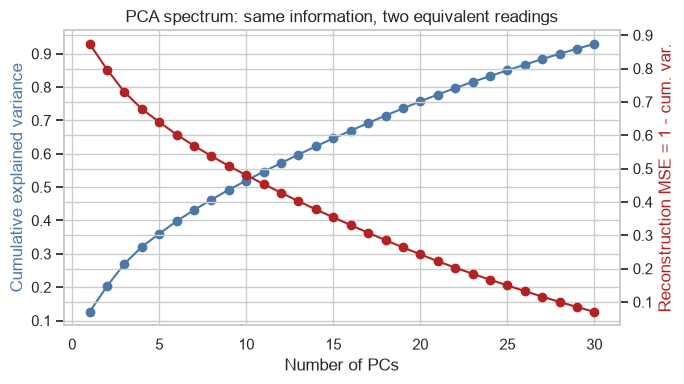

In [11]:
N_COMPS_FIT = 30
sc.tl.pca(adata, n_comps=N_COMPS_FIT, svd_solver="arpack", random_state=RANDOM_SEED)
X_pca_full = np.asarray(adata.obsm["X_pca"], dtype=np.float32)  # (n_cells, 30)

cumulative_var = np.cumsum(adata.uns["pca"]["variance_ratio"])

# Reconstruction error and cumulative explained variance are two views of the same spectrum,
# not independent evidence: for standardized (z-scored) input, keeping the top k components
# gives reconstruction MSE = 1 - cumulative_explained_variance(k). We show this once as a
# derived curve rather than plotting an "elbow" and a separately-fit "reconstruction error"
# curve, which would just be the same information mirrored.
reconstruction_mse = 1 - cumulative_var

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(np.arange(1, N_COMPS_FIT + 1), cumulative_var, marker="o", color="#4c78a8", label="cumulative explained variance")
ax1.set_xlabel("Number of PCs")
ax1.set_ylabel("Cumulative explained variance", color="#4c78a8")
ax2 = ax1.twinx()
ax2.plot(np.arange(1, N_COMPS_FIT + 1), reconstruction_mse, marker="o", color="firebrick", label="reconstruction MSE (derived)")
ax2.set_ylabel("Reconstruction MSE = 1 - cum. var.", color="firebrick")
ax1.set_title("PCA spectrum: same information, two equivalent readings")
plt.tight_layout()
plt.show()

In [12]:
# Numerical check that the derived formula actually matches an empirical reconstruction,
# at the number of components we are about to choose
VARIANCE_THRESHOLD = 0.90
N_COMPONENTS_SELECTED = int(np.searchsorted(cumulative_var, VARIANCE_THRESHOLD) + 1)

pca_check = PCA(n_components=N_COMPONENTS_SELECTED, random_state=RANDOM_SEED)
X_check = pca_check.fit_transform(X)
X_reconstructed = pca_check.inverse_transform(X_check)
empirical_mse = np.mean((X - X_reconstructed) ** 2)
derived_mse = reconstruction_mse[N_COMPONENTS_SELECTED - 1]

print(f"Selected {N_COMPONENTS_SELECTED} PCs to reach {VARIANCE_THRESHOLD:.0%} cumulative explained variance")
print(f"Empirical reconstruction MSE: {empirical_mse:.4f}   Derived (1 - cum.var.): {derived_mse:.4f}")

X_pca = X_pca_full[:, :N_COMPONENTS_SELECTED]  # PCA components are nested, so this slice
                                                # is identical to refitting with N_COMPONENTS_SELECTED

Selected 29 PCs to reach 90% cumulative explained variance
Empirical reconstruction MSE: 0.0850   Derived (1 - cum.var.): 0.0850


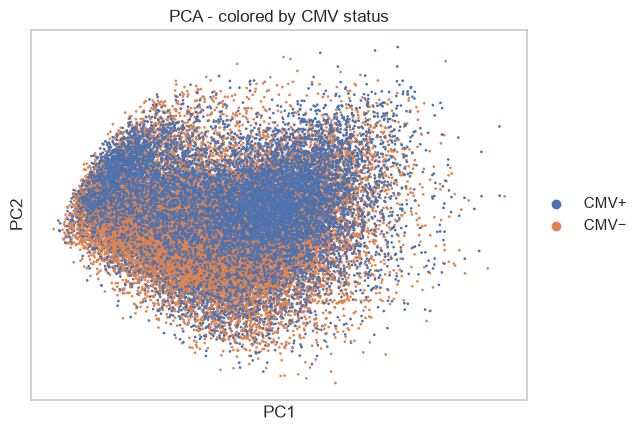

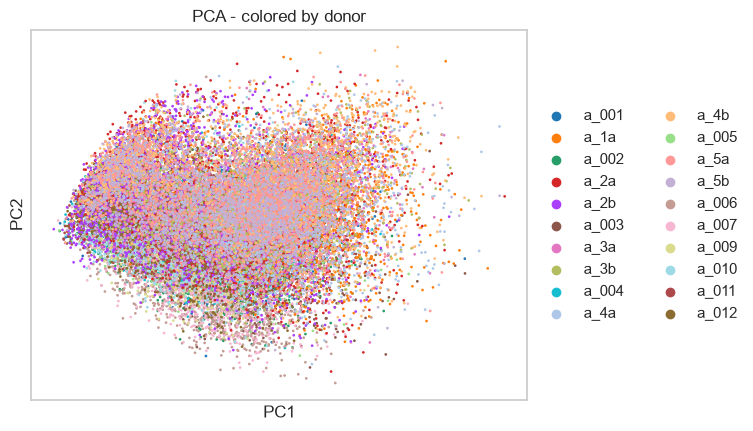

c:\Users\marie\anaconda3\envs\ssbi-group-project\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8942 (\N{VERTICAL ELLIPSIS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


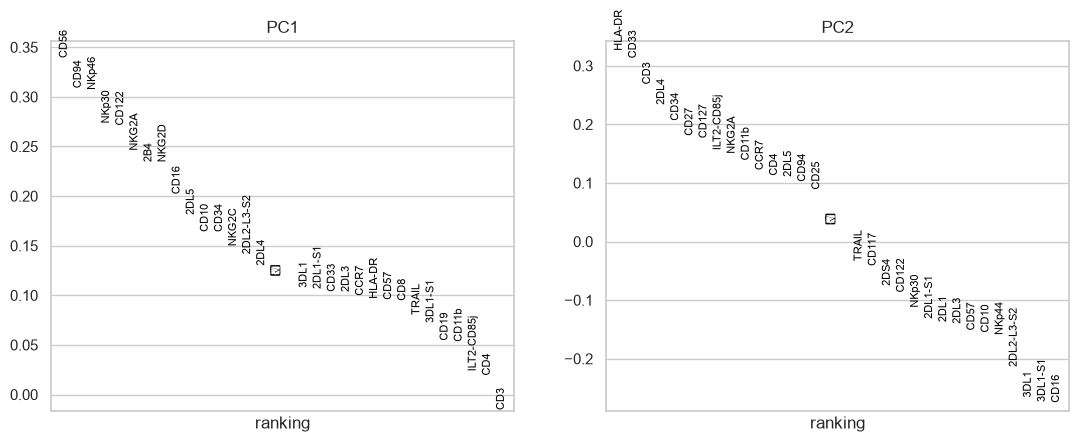

In [13]:
# 2D visualization: colored by CMV clinical group, and by donor to check for donor-driven
# structure/batch effects.
sc.pl.pca(adata, color="clinical_group", dimensions=(0, 1), title="PCA - colored by CMV status", size=15)
sc.pl.pca(adata, color="sample_id", dimensions=(0, 1), title="PCA - colored by donor", size=15)

# Marker loadings on PC1/PC2, for interpreting what the axes represent biologically.
sc.pl.pca_loadings(adata, components=[1, 2])

## 5. A fixed subsample for expensive hyperparameter sweeps

t-SNE and UMAP each have parameters that materially change the resulting layout, and the only
reliable way to pick sensible values is to sweep them and look at both the picture and a
quantitative preservation score. scikit-learn's t-SNE in particular does not scale well to the
full 40k cells, so all sweeps are run on a smaller, fixed 5,000-cell subsample drawn from the (already
donor-balanced) data. The best t-SNE parameters are choosen to a run with the full dataset. 
UMAP scales far better and runs also once on the full data
for the marker-overlay plots, using whichever settings the sweep selects.

In [14]:
SWEEP_N_CELLS = 5000
sweep_idx = np.sort(np.random.default_rng(RANDOM_SEED).choice(len(X_pca), SWEEP_N_CELLS, replace=False))
X_pca_sweep = X_pca[sweep_idx]
clinical_group = adata.obs["clinical_group"].to_numpy()
sample_ids = adata.obs["sample_id"].to_numpy()

# Check: does the sweep subsample still cover all donors reasonably? (A skewed draw would
# make the sweep's quantitative scores donor-biased.)
donor_counts_full = pd.Series(sample_ids).value_counts()
donor_counts_sweep = pd.Series(sample_ids[sweep_idx]).value_counts()
donor_coverage = pd.concat([donor_counts_full.rename("full"), donor_counts_sweep.rename("sweep")], axis=1)
print(f"Donors in sweep subsample: {donor_coverage['sweep'].notna().sum()} / {donor_coverage.shape[0]}")
donor_coverage.sort_values("sweep")

Donors in sweep subsample: 20 / 20


,full,sweep
a_2a,2000,220
a_1a,2000,225
a_001,2000,234
a_005,2000,236
a_009,2000,236
a_4b,2000,240
a_006,2000,245
a_5b,2000,246
a_012,2000,247
a_3a,2000,249


In [15]:
def knn_preservation(X_high, X_low, k=15):
    """Fraction of each point's k nearest neighbors shared between two representations.
    Symmetric in its two arguments (unlike trustworthiness), so it is also usable to compare
    two embeddings to each other directly, not just an embedding to a high-D reference."""
    nn_high = NearestNeighbors(n_neighbors=k + 1).fit(X_high)
    nn_low = NearestNeighbors(n_neighbors=k + 1).fit(X_low)
    idx_high = nn_high.kneighbors(return_distance=False)[:, 1:]
    idx_low = nn_low.kneighbors(return_distance=False)[:, 1:]
    overlap = [len(set(a) & set(b)) / k for a, b in zip(idx_high, idx_low)]
    return np.mean(overlap)


def plot_param_sweep_grid(results, param_labels, n_cols=4, color_by=None):
    n = len(results)
    n_rows = math.ceil(n / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 3.2 * n_rows), squeeze=False)
    axes = axes.ravel()
    for ax, res, label in zip(axes, results, param_labels):
        emb = res["embedding"]
        ax.scatter(emb[:, 0], emb[:, 1], c=color_by, cmap="tab10", s=3, alpha=0.6)
        ax.set_title(f"{label}\ntw={res['trustworthiness']:.3f}", fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])
    for ax in axes[n:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

## 6. t-SNE parameter sweep

**Parameters:** the main one is `perplexity`, which roughly sets how many neighbors t-SNE
tries to preserve per point (conceptually similar to UMAP's `n_neighbors`, though the
underlying mechanism -- a probability distribution over neighbors, optimized to match a
low-D counterpart -- is different). Others (`learning_rate`, `n_iter`/`max_iter`, `init`)
mostly affect optimization stability/convergence rather than the qualitative structure of the
result, so we fix those to reasonable defaults (`init="pca"` for reproducible, well-conditioned
starts; enough iterations to converge) and sweep only perplexity.

- **Low perplexity** (e.g. 5): optimizes only very local neighborhoods -> tends to fragment
  the data into many small, tight islands, some of which are optimization artifacts rather
  than real structure.
- **High perplexity** (e.g. 100): preserves much larger neighborhoods -> smoother, more
  "global-looking" layout, but risks merging genuinely distinct populations and losing fine
  local structure.
- Commonly recommended range: roughly 5-50; we sweep somewhat beyond that upper bound to see
  where degradation becomes visible.

In [16]:
tsne_param_grid = [{"perplexity": p} for p in [5, 30, 50, 60, 70, 100]]

tsne_sweep_results = []
for params in tsne_param_grid:
    tsne = TSNE(n_components=2, init="pca", random_state=RANDOM_SEED, n_jobs=6,
                max_iter=750, method="barnes_hut", **params)
    embedding = tsne.fit_transform(X_pca_sweep)
    tsne_sweep_results.append({
        **params,
        "trustworthiness": trustworthiness(X_pca_sweep, embedding, n_neighbors=15),
        "knn_preservation": knn_preservation(X_pca_sweep, embedding, k=15),
        "embedding": embedding,
    })

tsne_sweep_df = pd.DataFrame(tsne_sweep_results).drop(columns="embedding")
tsne_sweep_df.sort_values("trustworthiness", ascending=False)
best_tsne_perplexity = int(
    tsne_sweep_df.sort_values("trustworthiness", ascending=False).iloc[0]["perplexity"]
)

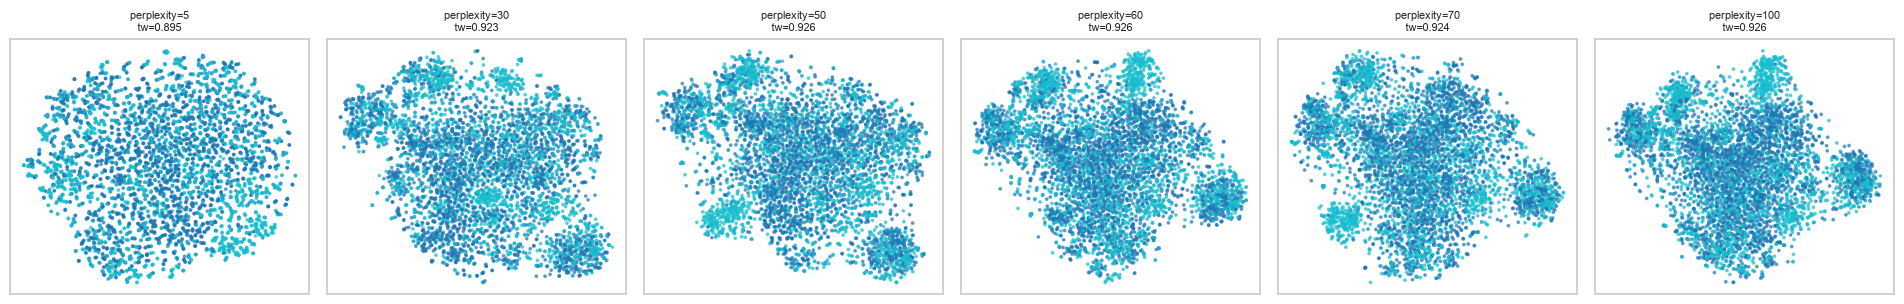

In [17]:
tsne_sweep_labels = [f"perplexity={r['perplexity']}" for r in tsne_sweep_results]
plot_param_sweep_grid(tsne_sweep_results, tsne_sweep_labels, n_cols=len(tsne_param_grid),
                       color_by=(clinical_group[sweep_idx] == "CMV+"))

In [18]:
tsne_full = TSNE(
    n_components=2,
    perplexity=best_tsne_perplexity,
    init="pca",
    random_state=RANDOM_SEED,
    n_jobs=1,
    max_iter=750,
    method="barnes_hut",
)
X_tsne_full = tsne_full.fit_transform(X_pca)

print(f"t-SNE on full data: {X_tsne_full.shape[0]:,} cells")

t-SNE on full data: 40,000 cells


## 7. UMAP parameter sweep

**Parameters:** `n_neighbors` (how many neighbors define the local fuzzy graph -- small values
emphasize very local structure, large values emphasize global structure, directly analogous to
t-SNE's perplexity) and `min_dist` (how tightly points are allowed to pack in the embedding --
small values produce tight, well-separated clusters, large values produce a more even, spread-out
layout that is easier to read distances from but blurs cluster boundaries).

In [19]:
umap_param_grid = [
    {"n_neighbors": nn, "min_dist": md}
    for nn in [5, 15, 30, 50]
    for md in [0.0, 0.1, 0.3, 0.5]
]

umap_sweep_results = []
for params in umap_param_grid:
    reducer = umap.UMAP(random_state=RANDOM_SEED, **params)
    embedding = reducer.fit_transform(X_pca_sweep)
    umap_sweep_results.append({
        **params,
        "trustworthiness": trustworthiness(X_pca_sweep, embedding, n_neighbors=15),
        "knn_preservation": knn_preservation(X_pca_sweep, embedding, k=15),
        "embedding": embedding,
    })

umap_sweep_df = pd.DataFrame(umap_sweep_results).drop(columns="embedding")
umap_sweep_df.sort_values("trustworthiness", ascending=False)

c:\Users\marie\anaconda3\envs\ssbi-group-project\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\marie\anaconda3\envs\ssbi-group-project\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\marie\anaconda3\envs\ssbi-group-project\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\marie\anaconda3\envs\ssbi-group-project\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\marie\anaconda3\envs\ssbi-group-project\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\marie\anaconda3\envs\ssbi-

,n_neighbors,min_dist,trustworthiness,knn_preservation
0,5,0.0,0.890139,0.174067
1,5,0.1,0.879145,0.161480
8,30,0.0,0.877151,0.140413
4,15,0.0,0.876539,0.150093
12,50,0.0,0.871496,0.130840
5,15,0.1,0.870988,0.137133
9,30,0.1,0.864245,0.127440
13,50,0.1,0.856671,0.116400
2,5,0.3,0.850586,0.130413
6,15,0.3,0.842617,0.107947


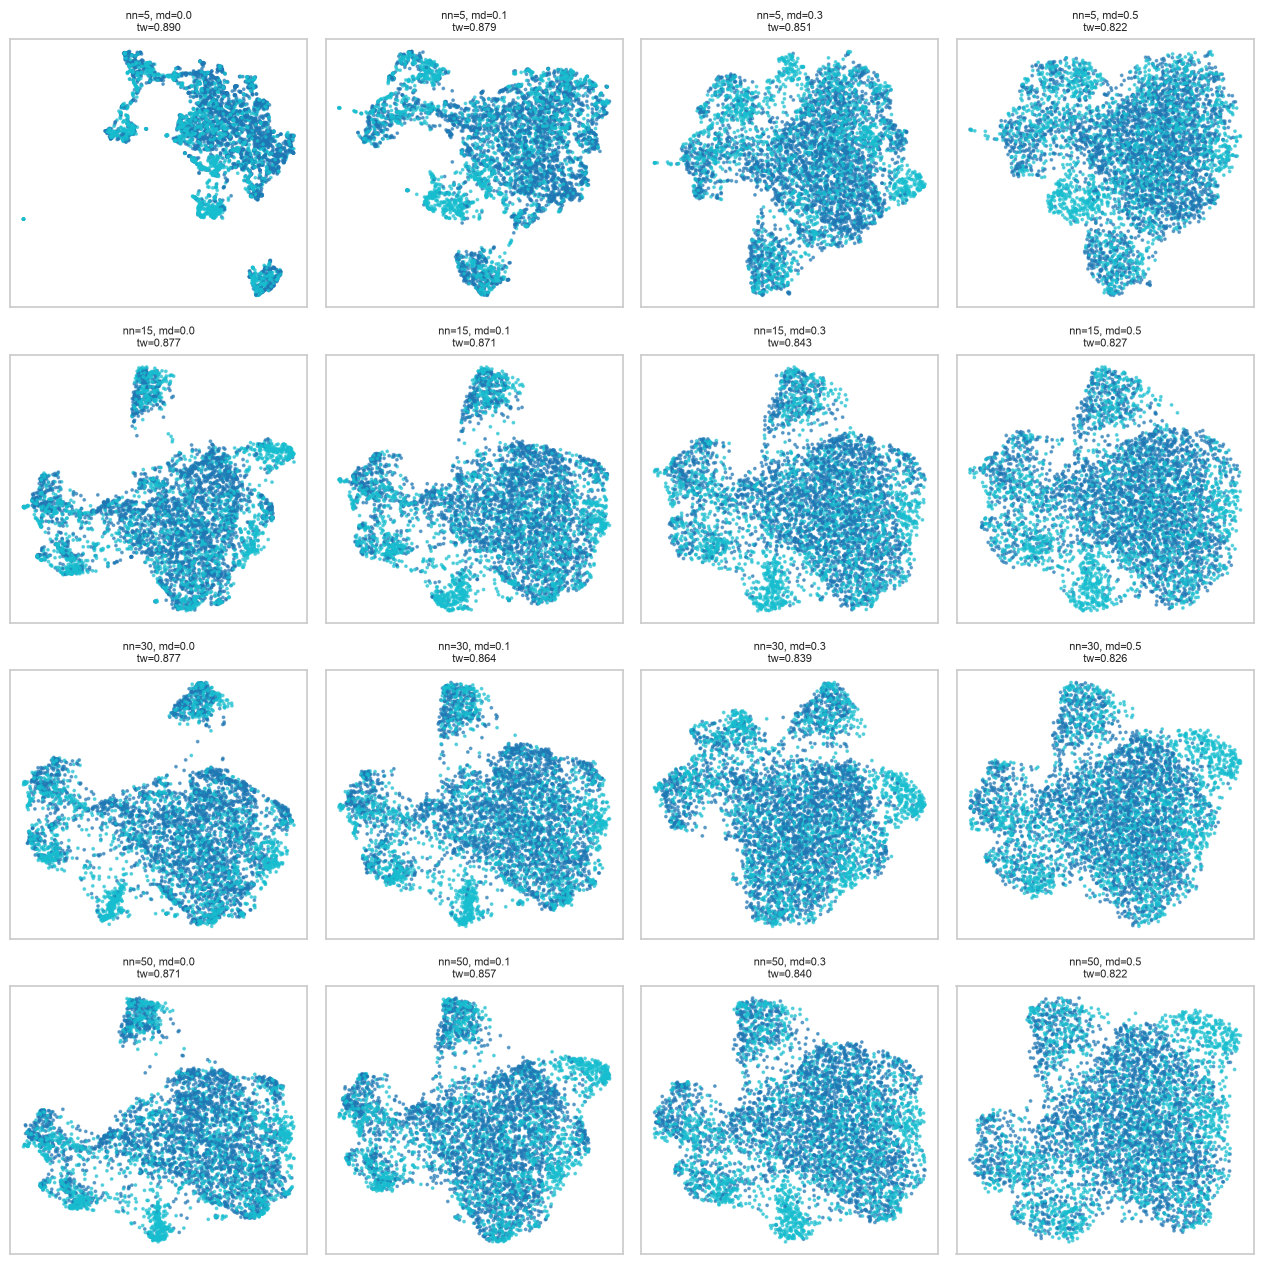

In [20]:
umap_sweep_labels = [f"nn={r['n_neighbors']}, md={r['min_dist']}" for r in umap_sweep_results]
plot_param_sweep_grid(umap_sweep_results, umap_sweep_labels, n_cols=4,
                       color_by=(clinical_group[sweep_idx] == "CMV+"))

## 8. Final embeddings

Parameters are read off the sweep tables (highest trustworthiness on the fixed subsample) so the choice is traceable and reproducible.

In [21]:
best_umap_row = umap_sweep_df.sort_values("trustworthiness", ascending=False).iloc[0]
best_umap_n_neighbors = int(best_umap_row["n_neighbors"])
best_umap_min_dist = float(best_umap_row["min_dist"])

print(f"Selected t-SNE perplexity: {best_tsne_perplexity}")
print(f"Selected UMAP params: n_neighbors={best_umap_n_neighbors}, min_dist={best_umap_min_dist}")

Selected t-SNE perplexity: 60
Selected UMAP params: n_neighbors=5, min_dist=0.0


In [22]:
# --- Subsample-scale embeddings (all on the same 5,000 cells) -> used for the fair,
# apples-to-apples quantitative comparison below.
X_pca_2d_sweep = X_pca_sweep[:, :2]

tsne_final = TSNE(n_components=2, perplexity=best_tsne_perplexity, init="pca",
                   random_state=RANDOM_SEED, n_jobs=6, max_iter=750, method="barnes_hut")
X_tsne_sweep = tsne_final.fit_transform(X_pca_sweep)

umap_final_sweep = umap.UMAP(n_neighbors=best_umap_n_neighbors, min_dist=best_umap_min_dist,
                              random_state=RANDOM_SEED, low_memory=True)
X_umap_sweep = umap_final_sweep.fit_transform(X_pca_sweep)

embeddings_sweep = {"PCA": X_pca_2d_sweep, "t-SNE": X_tsne_sweep, "UMAP": X_umap_sweep}

c:\Users\marie\anaconda3\envs\ssbi-group-project\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [23]:
# --- Full-scale embeddings (all cells) -> used for the marker-overlay / biological
# exploration plots, where more cells means better odds of spotting a rare subset.
X_pca_2d_full = X_pca[:, :2]

umap_final_full = umap.UMAP(n_neighbors=best_umap_n_neighbors, min_dist=best_umap_min_dist,
                             random_state=RANDOM_SEED, low_memory=True)

X_umap_full = umap_final_full.fit_transform(X_pca)

embeddings_full = {"PCA": X_pca_2d_full, "t-SNE": X_tsne_full, "UMAP": X_umap_full}

print(f"Full-scale embeddings ready for {len(X_pca):,} cells")

c:\Users\marie\anaconda3\envs\ssbi-group-project\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Full-scale embeddings ready for 40,000 cells


## 9. Visualizations

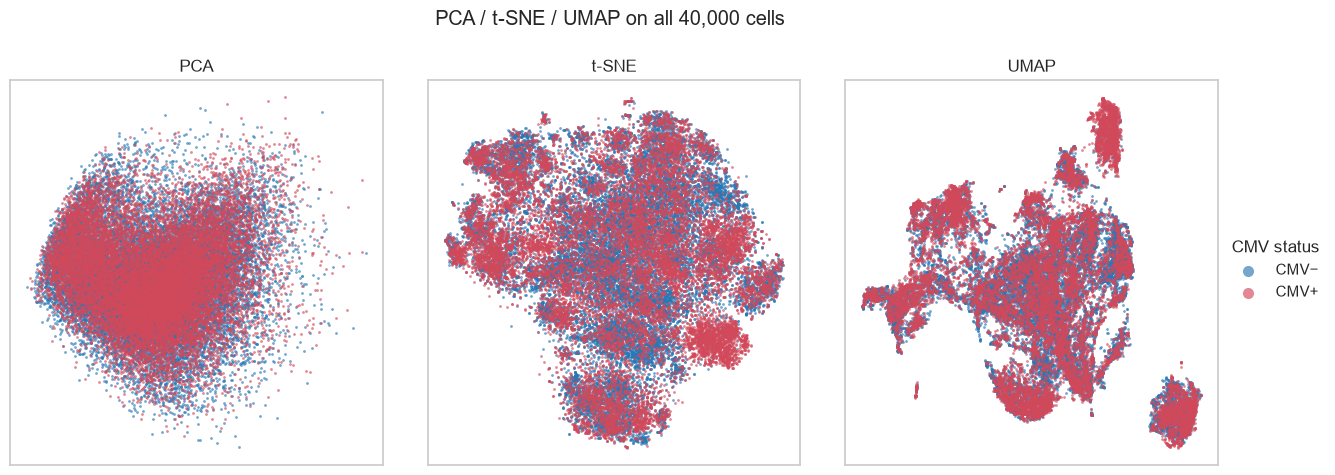

In [24]:
# --- Full-scale embeddings, colored by discrete CMV status ---
full_embeddings = {
    "PCA": X_pca_2d_full,
    "t-SNE": X_tsne_full,
    "UMAP": X_umap_full,
}

cmv_colors = {"CMV−": "#2878b5", "CMV+": "#d1495b"}
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, embedding) in zip(axes, full_embeddings.items()):
    for group, color in cmv_colors.items():
        mask = clinical_group == group
        ax.scatter(
            embedding[mask, 0],
            embedding[mask, 1],
            color=color,
            label=group,
            s=4,
            alpha=0.65,
            linewidths=0,
        )
    ax.set_title(name)
    ax.set_xticks([])
    ax.set_yticks([])

handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    legend_labels,
    title="CMV status",
    loc="center left",
    bbox_to_anchor=(0.88, 0.5),
    markerscale=4,
    frameon=False,
)
fig.suptitle(f"PCA / t-SNE / UMAP on all {len(clinical_group):,} cells", y=1.02)
fig.subplots_adjust(right=0.88, wspace=0.12)
plt.show()

**Marker overlay.** Coloring by CMV status shows at most a global shift; a rare subset like
adaptive NK cells (NKG2C+/CD57+) may only be visible when coloring continuously by individual
marker expression instead.

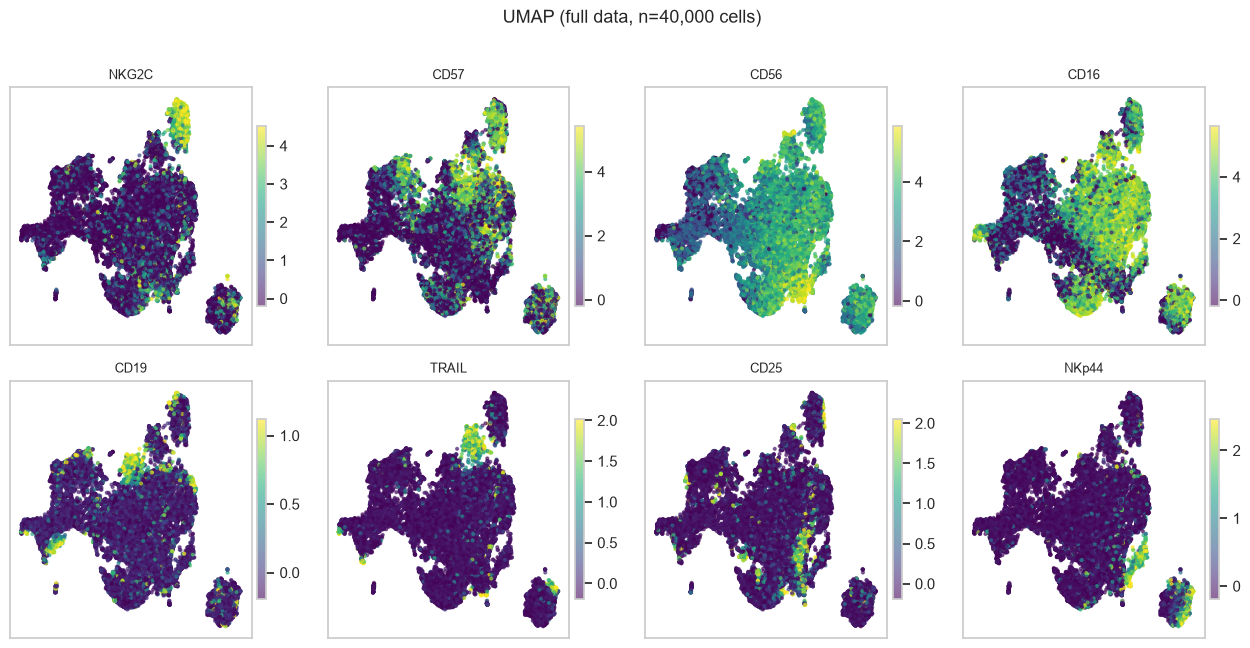

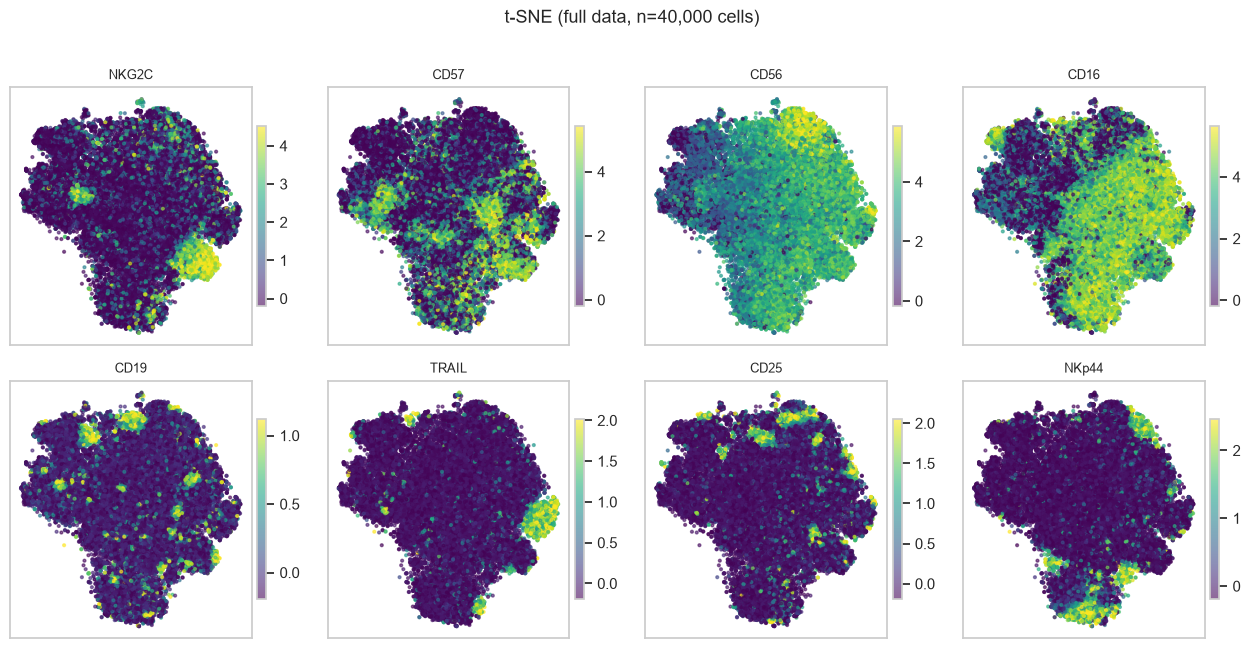

In [25]:
diagnostic_markers_for_overlay = ["NKG2C", "CD57", "CD56", "CD16", "CD19", "TRAIL", "CD25", "NKp44"]

def plot_embedding_by_markers(coords, marker_values, markers, title_prefix, n_cols=4,
                               point_size=4, alpha=0.6, clip_percentiles=(1, 99)):
    n_rows = math.ceil(len(markers) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 3.2 * n_rows), squeeze=False)
    axes = axes.ravel()
    for ax, marker in zip(axes, markers):
        values = marker_values[marker].to_numpy()
        vmin, vmax = np.percentile(values, clip_percentiles)
        sc_plot = ax.scatter(coords[:, 0], coords[:, 1], c=values, cmap="viridis",
                              s=point_size, alpha=alpha, vmin=vmin, vmax=vmax)
        ax.set_title(marker, fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
        fig.colorbar(sc_plot, ax=ax, shrink=0.7, pad=0.02)
    for ax in axes[len(markers):]:
        ax.axis("off")
    fig.suptitle(title_prefix, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

# Full-scale UMAP: maximal sensitivity to the rare subset (all cells).
marker_values_full = nk_transformed[diagnostic_markers_for_overlay]
plot_embedding_by_markers(X_umap_full, marker_values_full, diagnostic_markers_for_overlay,
                           f"UMAP (full data, n={len(X_umap_full):,} cells)")

# Full-scale t-SNE: same markers, all cells, for comparison with UMAP.
plot_embedding_by_markers(X_tsne_full, marker_values_full, diagnostic_markers_for_overlay,
                           f"t-SNE (full data, n={len(X_tsne_full):,} cells)")

## 10. Quantitative comparison of PCA / t-SNE / UMAP

We use two families of measures, since they capture different things:

**Neighbor-based (local structure):**
- *Trustworthiness* -- checks whether points that appear close in the low-D embedding were
  actually close in high-D; penalizes "false neighbors" introduced by the projection.
  Asymmetric: needs one side designated as the reference/ground truth.
- *kNN-preservation* (defined above) -- plain fraction of shared k-nearest-neighbors between
  two representations. Symmetric, so it also works to compare two embeddings directly to
  each other, not just an embedding to a high-D reference.

**Non-neighbor-based (global structure):**
- *Distance correlation* -- Pearson correlation between *all* pairwise distances in high-D vs.
  low-D (a Shepard-diagram-style measure), not just the k nearest ones. Captures whether the
  overall layout (relative placement of distant clusters) is preserved, which the kNN-based
  measures are blind to by construction.
- *Procrustes disparity* -- optimally rotate/scale/translate one 2D embedding onto another and
  measure the leftover mismatch. A natural way to compare two *embeddings* to each other (as
  opposed to an embedding to its high-D source), without any notion of "neighbors" at all.
- *Silhouette score on CMV status* -- not a structure-preservation measure, but directly
  answers the domain question of interest: how well does each projection separate the known
  CMV+/CMV- groups? Included because that is literally the paper's clinical variable of
  interest, not just a generic DR-quality proxy.

All neighbor-based and distance-correlation measures below use the same 5,000-cell subsample
and the same high-dimensional reference (`X_pca_sweep`) as the sweeps, so results are directly
comparable to the sweep tables above.

In [28]:
reference_space = X_pca_full

def distance_correlation(X_high, X_low, n_sample=2000, random_state=RANDOM_SEED):
    """Pearson correlation between pairwise distances in the high-D reference and the low-D
    embedding, computed on a random subset of points (pairwise distance count grows as
    O(n^2), so this keeps the computation lightweight)."""
    rng = np.random.default_rng(random_state)
    idx = rng.choice(len(X_high), size=min(n_sample, len(X_high)), replace=False)
    d_high = pdist(X_high[idx])
    d_low = pdist(X_low[idx])
    r, _ = pearsonr(d_high, d_low)
    return r

quality_rows = []
for name, emb in embeddings_full.items():
    quality_rows.append({
        "embedding": name,
        "trustworthiness": trustworthiness(reference_space, emb, n_neighbors=15),
        "knn_preservation": knn_preservation(reference_space, emb, k=15),
        "distance_correlation": distance_correlation(reference_space, emb),
        "silhouette_cmv": silhouette_score(emb, clinical_group),
    })

quality_df = pd.DataFrame(quality_rows).set_index("embedding")
quality_df

,trustworthiness,knn_preservation,distance_correlation,silhouette_cmv
embedding,,,,
PCA,0.724320,0.006730,0.617264,0.001623
t-SNE,0.959955,0.167185,0.484853,0.010436
UMAP,0.899225,0.082940,0.394753,0.017802


**Shepard diagrams** for the same three embeddings — a scatter of low-D distance against
high-D distance for the sampled point pairs; a perfect embedding would fall on the diagonal.

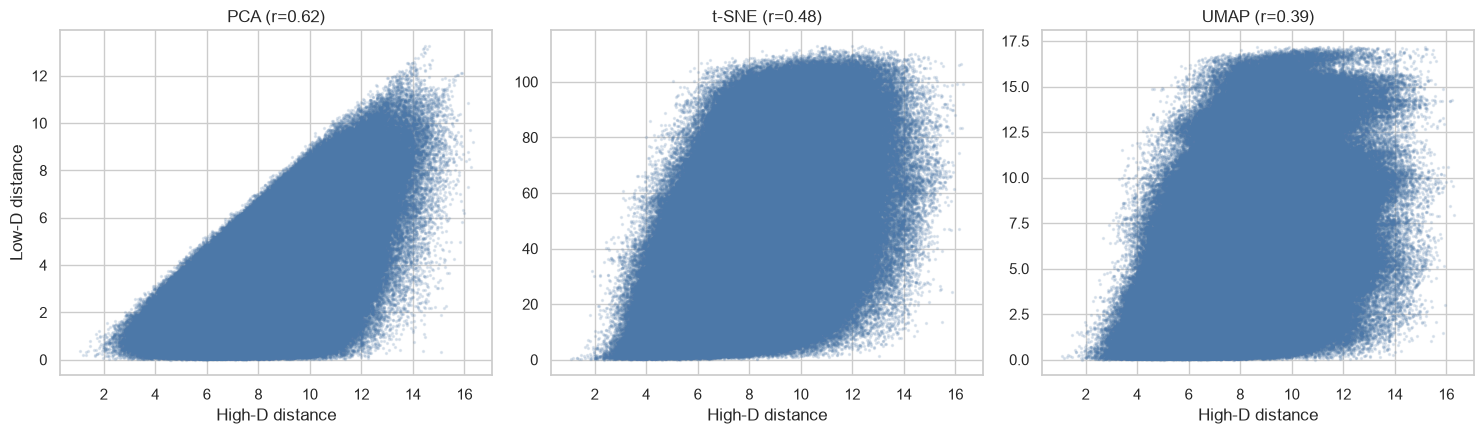

In [29]:
SHEPARD_N_SAMPLE = 2000
rng = np.random.default_rng(RANDOM_SEED)
shepard_idx = rng.choice(len(reference_space), size=SHEPARD_N_SAMPLE, replace=False)
d_high = pdist(reference_space[shepard_idx])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True)
for ax, (name, emb) in zip(axes, embeddings_full.items()):
    d_low = pdist(emb[shepard_idx])
    ax.scatter(d_high, d_low, s=2, alpha=0.15, color="#4c78a8")
    ax.set_title(f"{name} (r={quality_df.loc[name, 'distance_correlation']:.2f})")
    ax.set_xlabel("High-D distance")
axes[0].set_ylabel("Low-D distance")
plt.tight_layout()
plt.show()

**Pairwise comparison between the three embeddings themselves** (as opposed to each vs. the
high-D reference) -- for these we use the symmetric measures (kNN-preservation, Procrustes
disparity), since trustworthiness's asymmetry requires a designated ground-truth side, which
doesn't make sense when neither of the two embeddings being compared is the reference.

,pair,knn_preservation,procrustes_disparity
0,PCA vs t-SNE,0.005585,0.451891
1,PCA vs UMAP,0.003975,0.733897
2,t-SNE vs UMAP,0.105957,0.723692


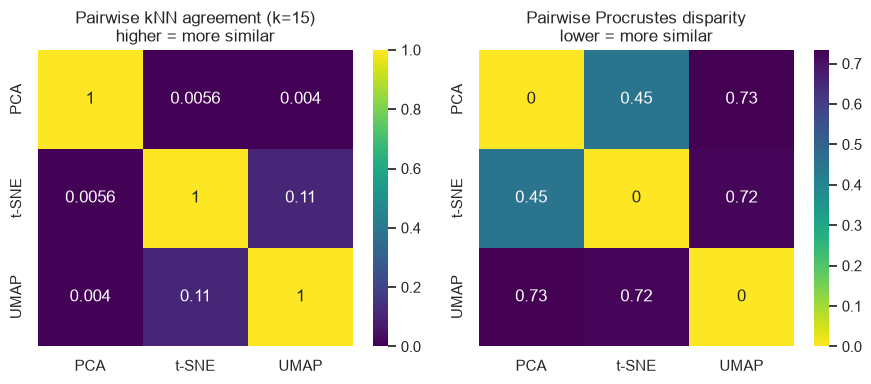

In [30]:
pair_rows = []
knn_matrix = pd.DataFrame(np.eye(3), index=embeddings_full.keys(), columns=embeddings_full.keys())
procrustes_matrix = pd.DataFrame(np.zeros((3, 3)), index=embeddings_full.keys(), columns=embeddings_full.keys())

for name_a, name_b in combinations(embeddings_full.keys(), 2):
    knn_score = knn_preservation(embeddings_full[name_a], embeddings_full[name_b], k=15)
    _, _, procrustes_disparity = procrustes(embeddings_full[name_a], embeddings_full[name_b])

    knn_matrix.loc[name_a, name_b] = knn_matrix.loc[name_b, name_a] = knn_score
    procrustes_matrix.loc[name_a, name_b] = procrustes_matrix.loc[name_b, name_a] = procrustes_disparity

    pair_rows.append({"pair": f"{name_a} vs {name_b}",
                       "knn_preservation": knn_score,
                       "procrustes_disparity": procrustes_disparity})

pairwise_df = pd.DataFrame(pair_rows)
display(pairwise_df)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
sns.heatmap(knn_matrix, annot=True, vmin=0, vmax=1, cmap="viridis", ax=axes[0])
axes[0].set_title("Pairwise kNN agreement (k=15)\nhigher = more similar")
sns.heatmap(procrustes_matrix, annot=True, cmap="viridis_r", ax=axes[1])
axes[1].set_title("Pairwise Procrustes disparity\nlower = more similar")
plt.tight_layout()
plt.show()

## 11. Summary

*(Fill in the actual numbers once this notebook has been run against the data -- this section
is the skeleton for the 1-page report.)*

- **Preprocessing:** arcsinh(c=5) + z-scoring on `N` retained markers (after dropping
  near-zero-variance markers); the donor-balanced subsample was checked against the full data
  and found representative for the rare adaptive-NK subset (or: found unreliable for donors
  X, Y, Z, which should be re-checked against full data downstream).
- **PCA:** `N_COMPONENTS_SELECTED` components reach 90% cumulative explained variance;
  PC1/PC2 show [donor-driven / CMV-driven / no obvious] separation.
- **t-SNE:** best trustworthiness at perplexity=`best_tsne_perplexity`.
- **UMAP:** best trustworthiness at n_neighbors=`best_umap_n_neighbors`,
  min_dist=`best_umap_min_dist`.
- **Quantitative comparison:** report which method scores highest on trustworthiness /
  kNN-preservation (local structure) vs. distance correlation (global structure) -- these can
  disagree, and that disagreement is itself a result worth stating, not a discrepancy to
  hide. Report the pairwise kNN/Procrustes numbers to say how similar the three layouts
  actually are to each other, not just how each compares to the high-D data individually.
- **Biology:** state whether the adaptive NK (NKG2C+/CD57+) subset is visible as a distinct
  region in the marker-overlay plots, and whether it aligns with CMV+ donors as expected from
  the paper.

## 12. Export for downstream clustering

Persists the subsample-scale embeddings (for anything that wants all three side by side) and
the full-scale PCA/UMAP embeddings (for clustering on the complete dataset).

In [31]:
embedding_export = pd.DataFrame({
    "sample_id": sample_ids[sweep_idx],
    "clinical_group": clinical_group[sweep_idx],
    "PC1": X_pca_2d_sweep[:, 0], "PC2": X_pca_2d_sweep[:, 1],
    #"tsne1": X_tsne_sweep[:, 0], "tsne2": X_tsne_sweep[:, 1],
    "umap1": X_umap_sweep[:, 0], "umap2": X_umap_sweep[:, 1],
})
embedding_export.to_parquet(ARTIFACT_DIR / "embeddings_comparison_subsample.parquet", index=False)

full_export = pd.DataFrame({
    "sample_id": sample_ids,
    "clinical_group": clinical_group,
    "PC1": X_pca[:, 0], "PC2": X_pca[:, 1],
    "tsne1": X_tsne_full[:, 0], "tsne2": X_tsne_full[:, 1],
    "umap1": X_umap_full[:, 0], "umap2": X_umap_full[:, 1],
})
full_export.to_parquet(ARTIFACT_DIR / "embeddings_full.parquet", index=False)
np.save(ARTIFACT_DIR / "X_pca_full.npy", X_pca)  # full N_COMPONENTS_SELECTED-dim PCA space, for clustering

print("Exported subsample and full-data embeddings for the clustering notebook.")

Exported subsample and full-data embeddings for the clustering notebook.
